# Setup

In [12]:
%load_ext autoreload
%autoreload 2
%cd -q ..

import pickle
import numpy as np
import os
import math
import sys
import pickle
import random
import importlib
import pandas as pd
import logging
import warnings
warnings.filterwarnings('ignore')

from copy import deepcopy
from itertools import product
from collections import defaultdict
from math import factorial, sqrt
from types import SimpleNamespace
from typing import Dict, List
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.lines import Line2D
from deap import creator, base, tools
from scipy.spatial.distance import cdist, pdist
from scipy.stats import mannwhitneyu, combine_pvalues, wilcoxon


from impl import config as cfg
from impl.core.domain_factory import DomainFactory
from impl.ads.mr.predefined import mr_set1, mr_set3
from impl.ads.scenario.scenario_definition import ScenarioDefinition
from impl.ads.utils.math_utils import calculate_auc_improvements, area_under_curve, calculate_ds_improvements,\
    calculate_improvements
from impl.ads.utils.visualization import visualize_archived_distinct_solutions, visualize_aed, \
    visualize_archived_solutions_by_gen, visualize_archive_solution_over_generations, \
    visualize_fitness_distribution, visualize_distinct_solution_over_simulations, \
    visualize_computational_efficiency_v2, _filter_by_thresholds, style_map, verbose_map, default_style

from impl.core.algorithm.base import Budget
from impl.core.algorithm.rnsga2 import selRNSGA2WithMemory
from impl.core.algorithm.rnsga3 import selRNSGA3WithMemory
from impl.core.mr.base_mr import Perturbations

verbose_map["ccea"] = "CoCoMagic"
verbose_map["ccea-c"] = "CoCoMagic\c"
verbose_map["ccea+ri"] = "CoCoMagic + RI"
verbose_map["ccea-c+ri"] = "CoCoMagic\c + RI"

# Workaround for scenario definition restructure
import impl.ads.scenario.scenario_definition as scen_def_module
import impl.ads.mr.mr as base_mr_module
import impl.core.algorithm as alg_module

sys.modules["impl.scenario.scenario_definition"] = scen_def_module
sys.modules["impl.mr.mr"] = base_mr_module
sys.modules["impl.algorithm"] = alg_module

logger = logging.getLogger(__name__)
logger.setLevel(logging.ERROR)

domain = DomainFactory("ads")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Prepare data

In [13]:
BASE = '/out/results'

exp_data = {
    'ccea-c': [
        '1748884695969-ccea-d240fc',
        '1748941748026-ccea-b9ac6b',
        '1748989829337-ccea-4ec741',
        '1749038770422-ccea-42ed4d',
        '1749777922892-ccea-2c25d2',
        '1749814642920-ccea-de1f87',
        '1749886823824-ccea-649444',
        '1749923655258-ccea-1ba284',
        '1751198102877-ccea-1addfe',
        '1751208800030-ccea-a4ce3b',
    ],
    'ccea': [
        '1753244710641-ccea-37da0a',
        '1753253587969-ccea-3f4538',
        '1753265201843-ccea-8736f6',
        '1753277995878-ccea-4f4a93',
        '1753288312696-ccea-90131b',
        '1753299743510-ccea-2fe213',
        '1753311062286-ccea-c5ffb6',
        '1753325640117-ccea-cbdc64',
        '1753337580322-ccea-4028eb',
        '1753350065570-ccea-bfd2a8',
    ],
    'ga': [
        '1748973401212-ga-159d20',
        '1749020894373-ga-0c91c0',
        '1749070990957-ga-e5c457',
        '1749117177309-ga-e90e3a',
        '1749801622497-ga-1bf740',
        '1749865564502-ga-d4aeee',
        '1749911224188-ga-398954',
        '1749948108048-ga-cf2ad2',
        '1755546683848-ga-ae4399',
        '1755582174116-ga-4c68ce',
    ],
    'rs': [
        '1748904187579-rs-eb1239',
        '1749004788416-rs-6bf5f1',
        '1749054600895-rs-2ed24b',
        '1749101043616-rs-24f811',
        '1749789337635-rs-395f0a',
        '1749852996207-rs-73049d',
        '1749897744564-rs-122ef9',
        '1749934847144-rs-a62c00',
        '1755533345878-rs-34b8ed',
        '1755568778720-rs-1f9a96',
    ],
    'ccea-c+ri': [
        '1750434085129-ccea-ddb606',
        '1750449704726-ccea-5b378e',
        '1750463599493-ccea-3174c7',
        '1750474241344-ccea-de114c',
        '1750486589729-ccea-d7ee1e',
        '1750497161663-ccea-e0eee8',
        '1751223236951-ccea-ca103a',
        '1751231897173-ccea-a652fa',
        '1751243485332-ccea-36643e',
        '1751274772053-ccea-ac5042',
    ],
    'ccea+ri': [
        '1750785163861-ccea-21aab6',
        '1750803393939-ccea-e46291',
        '1750816760201-ccea-a491e1',
        '1750840993246-ccea-b56d46',
        '1750874763838-ccea-c37984',
        '1751052499693-ccea-37549d',
        '1751064557270-ccea-8d3741',
        '1751327671761-ccea-fa8901',
        '1755655938747-ccea-dc4280',
        '1755673172607-ccea-248354',
    ],
    'ccea-budget500': [
        '1753629887471-ccea-a574d1',
        '1753655503296-ccea-c22942',
        '1753682701323-ccea-ad3eab',
        '1753709801308-ccea-075fce',
        '1753734302443-ccea-ef5412',
        '1753755439514-ccea-7faff3',
        '1753799557159-ccea-e68788',
        '1753826910130-ccea-363aca',
        '1753861383229-ccea-9ab0f8',
    ],
    'ga-budget500': [
        '1753986957882-ga-c72b04',
        '1754205177517-ga-a3535a',
        '1754284712018-ga-539f97',
        '1754355391649-ga-2b0c39',
        '1754492634229-ga-c7ba05',
        '1754558445884-ga-e5fb67',
        '1754625896055-ga-9d5c89',
        '1754693081446-ga-3c5903',        
        '1754766932867-ga-b3561f',
        '1754797643721-ga-46e0c3',
    ],
    'rs-budget500': [
        '1754073826949-rs-f3eebf',
        '1754113994059-rs-b5e6b4',
        '1754324591780-rs-8182a5',
        '1754399240427-rs-061866',
        '1754460587756-rs-a9f563',
        '1754526105694-rs-684a1a',
        '1754594586253-rs-e2b4b0',
        '1754660930610-rs-d94e3d',
        '1754735354981-rs-9af071',
        '1754811501780-rs-a3f214',
    ],
}

mr3_data = {
    'ccea': [
        '1756962400980-ccea-e1c341',
        '1757044601762-ccea-f81ee0',
        '1757135841839-ccea-eccc01',
        '1757226358621-ccea-89b4a1',
        '1757317259134-ccea-d6b04c',
        '1757358052073-ccea-70d0c0',
        '1757493283222-ccea-c887e0',
        '1757508645471-ccea-3d074a',
        '1757448820563-ccea-ed36fb',
        '1757556648440-ccea-ec8246',
    ],
    'ga': [
        '1756945440242-ga-aa9aba',
        '1756987187617-ga-675de2',
        '1757028292092-ga-b28cb9',
        '1757115952500-ga-b28470',
        '1757162502360-ga-03c1e3',
        '1757206847572-ga-0c8475',
        '1757426267036-ga-b264d9',
        '1757474783304-ga-ba4dc1',
        '1757535257589-ga-64790c',
        '1757583797098-ga-9dad2c',
    ],
    'rs': [
        '1757014155216-rs-324788',
        '1757057362118-rs-731896',
        '1757102171187-rs-12dcae',
        '1757148157756-rs-a91a1e',
        '1757193349710-rs-33c2ad',
        '1757285926110-rs-8c97b6',
        '1757411605620-rs-3b07f3',
        '1757460412714-rs-d2d444',
        '1757520967895-rs-888283',
        '1757570220568-rs-404fdb',
    ],
}

runs_2026 = {
    'ccea-c': [
        '1770083186673-ccea-866794',
        '1770113743657-ccea-c0df4b',
        '1770141244797-ccea-fa1b37',
        '1770170873331-ccea-36ba25',
        '1770225187744-ccea-7135e7',
        '1770252820518-ccea-b98a0b',
        '1770285314059-ccea-4bee83',
        '1770313923351-ccea-9edc67',
        '1770341161164-ccea-9a38da',
        '1770374668383-ccea-5cea56',

    ],
    'ccea': [
        '1772306083018-ccea-9ec8ed',
        '1772337089769-ccea-9a74d6',
        '1772367914955-ccea-7ce7ea',
        '1772392260579-ccea-eea281',
        '1772422653593-ccea-d50407',
        '1772450688801-ccea-cb0ae1',
        '1772468319090-ccea-7d1cfa',
        '1772488560319-ccea-a20c20',
        '1772516867790-ccea-884678',
        '1772547983441-ccea-2dcdad',
    ],
    'ga': [
        '1771958606715-ga-0fd171',
        '1771990475940-ga-0e1f83',
        '1772025837171-ga-c69e32',
        '1772059684370-ga-16f548',
        '1772094754060-ga-454e34',
        '1772140130107-ga-69f752',
        '1772165885347-ga-797c6b',
        '1772231265178-ga-bb63db',
        '1772262575421-ga-606a97',
        '1772661804654-ga-b3bcd0',
    ],

    'rs': [
        '1770576147587-rs-262c8a',
        '1770606205619-rs-495169',
        '1770671276916-rs-628792',
        '1770703327488-rs-d8614d',
        '1770734389077-rs-f30327',
        '1770800734983-rs-f6dd24',
        '1770832937979-rs-cf0ff1',
        '1770875963400-rs-37e1e8',
        '1771011746713-rs-8739ec',
        '1771186004494-rs-58d1ad',
    ],

}

# Plots for RQ1

In [14]:
def quantile(projects, min_fitness=0.5):
    fitnesses = []
    dists = []
    for name, runs in projects.items():
        for run in runs:
            solution_file = next((cfg.CONFIG["workspace"]["result"] / run / "solutions").rglob("solutions*"), None)
            if solution_file is None: print(run)
            with open(solution_file, "rb") as f:
                solutions = pickle.load(f)
            fitnesses += [sol.fitness.values[0] for sol in solutions if sol.fitness.values[0] >= min_fitness]
            if len(solutions) < 2:
                print(f"{run}: {len(solutions)}")
                continue
            follow_ups = []
            for sol in solutions:
                if sol.fitness.values[0] < min_fitness: continue
                scenario, perturbation = sol[0], sol[1]
                perturbation.perturb(scenario)
                follow_ups.append(scenario)
            if len(follow_ups) > 1:
                dist = pdist(np.array(follow_ups, dtype=object).reshape((len(follow_ups), -1)),
                             lambda x, y: x[0].dist(y[0]))
                dists = np.concatenate((dists, dist))
    return fitnesses, dists

rq1_projects = {
    'ccea': runs_2026['ccea'],
    'ga': runs_2026['ga'],
    'rs': runs_2026['rs'],
}

fitnesses, dists = quantile(rq1_projects, min_fitness=0.1)
print('Fitness quantiles: ', np.quantile(fitnesses, [0.25, 0.5, 0.75,]).round(1), f', Average Fitness: {np.mean(fitnesses):.2f}')
print('Distance Quantiles: ', np.quantile(dists, [0.25, 0.5, 0.75, 0.95]).round(1), f', Average Distance: {np.mean(dists):.2f}')

Fitness quantiles:  [0.3 0.7 1.5] , Average Fitness: 1.08
Distance Quantiles:  [2.5 3.  3.5 4.2] , Average Distance: 2.99


## Average DS

Average improvement of ccea compared to ga: 68.72% (p-value = 8.8e-53)
Average improvement of ccea compared to rs: 142.37% (p-value = 3.1e-69)


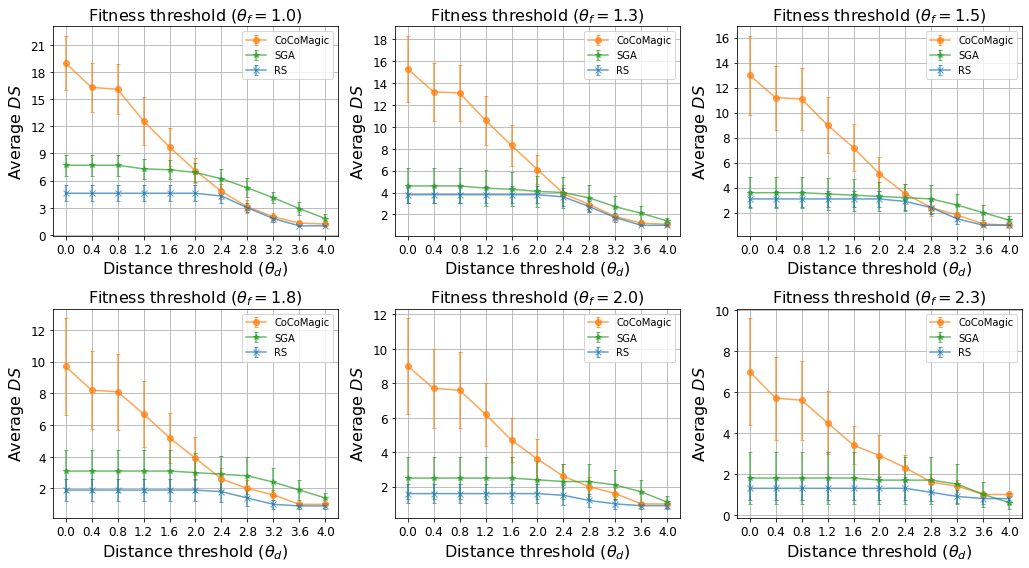

In [15]:
set1_solution_stats = visualize_archived_distinct_solutions(
    rq1_projects,
    comparisons = {'algs': ['ccea'], 'baselines': ['ga', 'rs']},
    fitness_thresholds=[1.0, 1.3, 1.5, 1.8, 2, 2.3],
    distance_thresholds=np.arange(0, 4.01, 0.4).round(1),
    mr_set=mr_set1,
    box=False,
    show=True
)

## Fitness Distribution

Average Fitness improvement of ccea (1.35) compared to ga (0.80): 69.20% (p-value = 2.3e-12)
Average Fitness improvement of ccea (1.35) compared to rs (0.97): 39.21% (p-value = 6.7e-04)


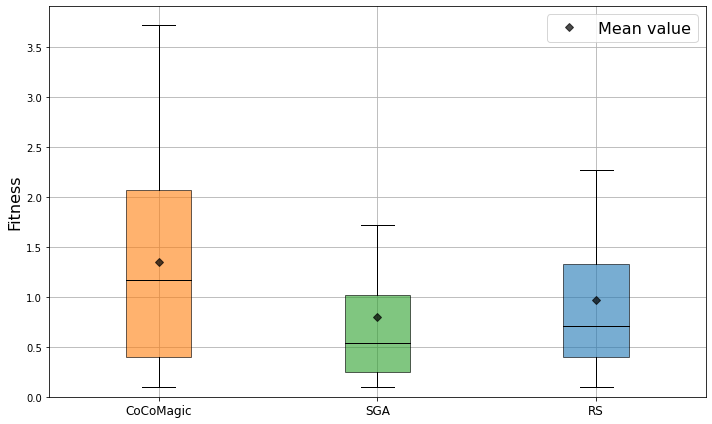

In [16]:
set1_fitnesses = visualize_fitness_distribution(rq1_projects, comparisons={'algs': ['ccea'], 'baselines': ['ga', 'rs',]}, min_fitness=0.1)

# RQ 2

In [17]:
rq2_projects = {
    'ccea': runs_2026['ccea'],
    'ga': runs_2026['ga'],
    'rs': runs_2026['rs'],
}

fitnesses, dists = quantile(rq2_projects, min_fitness=0.1)
print('Fitness quantiles: ', np.quantile(fitnesses, [0.25, 0.5, 0.75, 0.9]).round(1), f', Average Fitness: {np.mean(fitnesses):.2f}')
print('Distance Quantiles: ', np.quantile(dists, [0.1, 0.25, 0.5]).round(1), f', Average Distance: {np.mean(dists):.2f}')

Fitness quantiles:  [0.3 0.7 1.5 2.7] , Average Fitness: 1.08
Distance Quantiles:  [2.  2.5 3. ] , Average Distance: 2.99


Average improvement of ccea compared to ga: 136.13% (p-value = 3.8e-03)
Average improvement of ccea compared to rs: 154.61% (p-value = 3.8e-03)


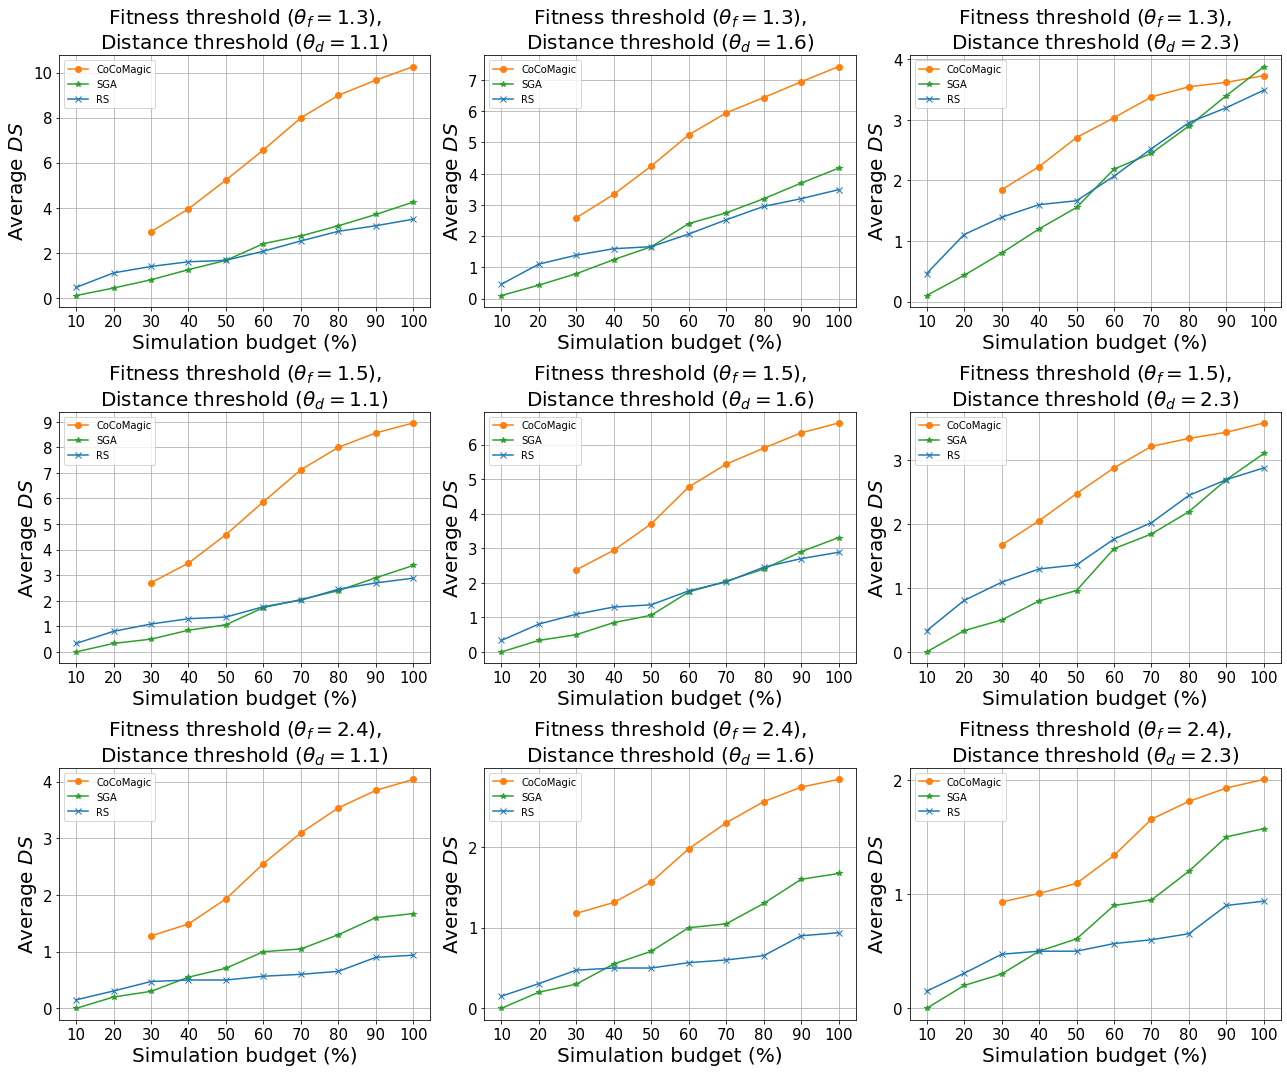

In [18]:
visualize_distinct_solution_over_simulations(rq2_projects,
    fitness_thresholds=[1.3, 1.5, 2.4], distance_thresholds=[1.1, 1.6, 2.3],
    max_sim_num=500, interval=10, mrc=False, mr_set=mr_set1, show=True)

# Computational Efficiency

In [19]:
from datetime import datetime
from matplotlib.lines import Line2D

def visualize_computational_efficiency_v2(projects: Dict[str, List[str]], save_path=None, show=False):
    """
    Generate a boxplot comparing computational efficiency (duration in hours) across algorithms without a logfile (version 2.0).

    :param projects: Project names of different algorithms. ``Dict[name_of_algorithm, List[project_name]]``.
    :param save_path: The path to save the figure.
    :param show: A boolean to determine whether to show the plots or not.
    """
    exec_data = {}
    for alg, runs in projects.items():
        exec_data[alg] = []
        for i, project in enumerate(runs):
            config_file = cfg.CONFIG["workspace"]["result"] / project / "config.json"
            solution_file = next((cfg.CONFIG["workspace"]["result"] / project / "solutions") \
                                 .rglob("solutions*"), None)

            start_time = datetime.fromtimestamp(config_file.stat().st_ctime)
            end_time = datetime.fromtimestamp(solution_file.stat().st_ctime)
            duration = end_time - start_time
            duration_hour = duration.total_seconds() / 3600
            exec_data[alg].append(duration_hour)

    height = 4
    title_size, text_size, tick_size = height * 5, height * 4, height * 3
    fig = plt.figure(figsize=(height * 2, height * 2))
    box = plt.boxplot(exec_data.values(), labels=[verbose_map.get(alg, alg) for alg in exec_data.keys()],
                      patch_artist=True,
                      medianprops=dict(color='black'),
                      showfliers=False)

    for patch, color in zip(box['boxes'], [style_map.get(alg, default_style)["color"] for alg in exec_data.keys()]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    exec_data_fil = {}
    for i, alg in enumerate(exec_data.keys(), start=1):
        data = np.array(exec_data[alg])
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # keep only non-outliers
        filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
        exec_data_fil[alg] = filtered_data.tolist()
        plt.scatter([i] * len(filtered_data), filtered_data, alpha=0.7,
                    color=style_map.get(alg, default_style)["color"])

        trimmed_mean = np.mean(filtered_data)
        plt.scatter(i, trimmed_mean, marker='D', s=40,
                    color='black', zorder=3, label='_nolegend_')

    calculate_improvements(
        data=exec_data_fil,
        comparison_algs={"algs": ["ccea"], "baselines": ["ga", "rs"]},
        metric_name="Computational Efficiency",
        higher_is_better=False,
    )

    # plt.title('Comparison of Computational Efficiency (Duration in Hours)', fontsize=title_size)
    plt.xlabel("Algorithm", fontsize=text_size)
    plt.ylabel("Duration (Hours)", fontsize=text_size)
    plt.tick_params(labelsize=tick_size)
    plt.grid(axis="y", linestyle='--')
    plt.legend(handles=[Line2D([0], [0], marker="D", markerfacecolor="black", markeredgecolor="black",
                               color="w", alpha=0.7, linestyle="None", label="Mean value")], fontsize=text_size)
    plt.tight_layout()
    fig.tight_layout()
    fig.savefig(save_path if save_path else (cfg.CONFIG["workspace"]["visualization"] / "computational_efficiency.pdf"))
    if show: plt.show()


Average Computational Efficiency improvement of ccea (7.44) compared to ga (8.99): 17.24% (p-value = 3.1e-03)
Average Computational Efficiency improvement of ccea (7.44) compared to rs (8.91): 16.49% (p-value = 3.8e-04)


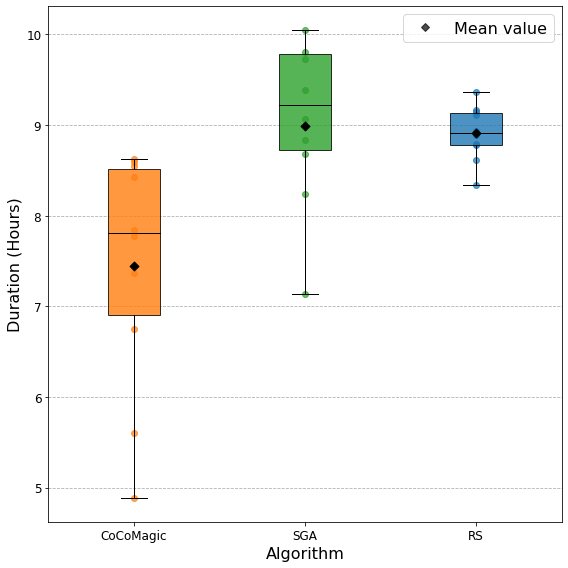

In [20]:
set2_comp_eff = visualize_computational_efficiency_v2(rq2_projects)

# RQ3

## Average DS

Average improvement of ccea compared to ccea-c: -21.67% (p-value = 2.0e-03)
Average improvement of ccea-c+ri compared to ccea-c: -23.74% (p-value = 5.7e-08)
Average improvement of ccea+ri compared to ccea-c: -39.19% (p-value = 3.4e-12)


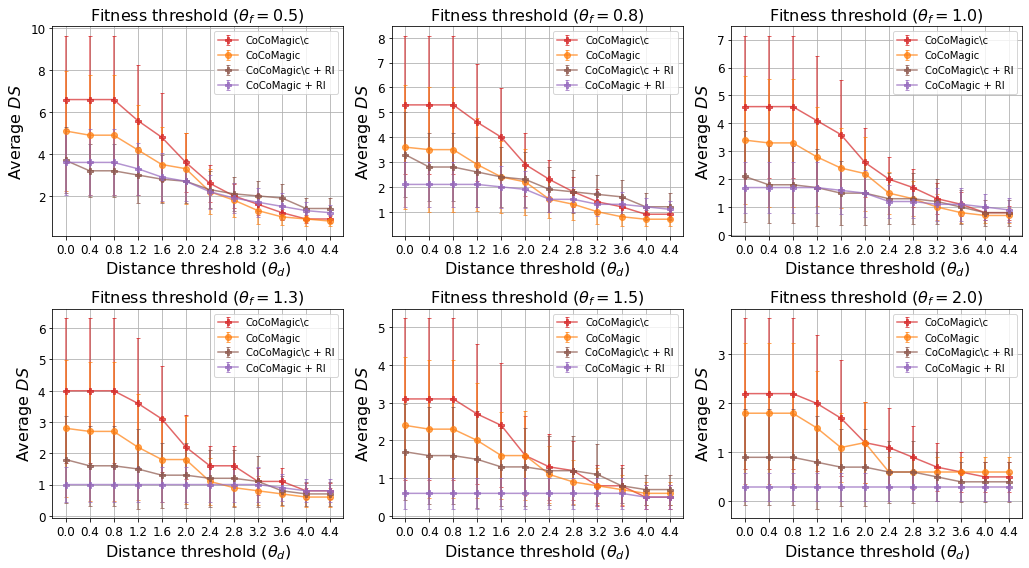

In [9]:
rq3_projects = {
    'ccea-c': exp_data['ccea-c'],
    'ccea': exp_data['ccea'],
    'ccea-c+ri': exp_data['ccea-c+ri'],
    'ccea+ri': exp_data['ccea+ri'],
}

comparisons = {'algs': ['ccea', 'ccea-c+ri', 'ccea+ri'], 'baselines': ['ccea-c']}

set3_solution_stats = visualize_archived_distinct_solutions(
    rq3_projects,
    comparisons = comparisons,
    fitness_thresholds=[0.5, 0.8, 1.0, 1.3, 1.5, 2],
    distance_thresholds=np.arange(0, 4.41, 0.4).round(1),
    mr_set=mr_set1,
    box=False,
    show=True,
    save_path=(cfg.CONFIG["workspace"]["visualization"] / "config_comparison.pdf"),
)

# AED

Average AED improvement of ccea (3.72) compared to ccea-c (3.94): 5.73% (p-value = 2.1e-01)
Average AED improvement of ccea-c+ri (4.87) compared to ccea-c (3.94): -23.46% (p-value = 1.0e+00)
Average AED improvement of ccea+ri (4.34) compared to ccea-c (3.94): -10.02% (p-value = 9.6e-01)


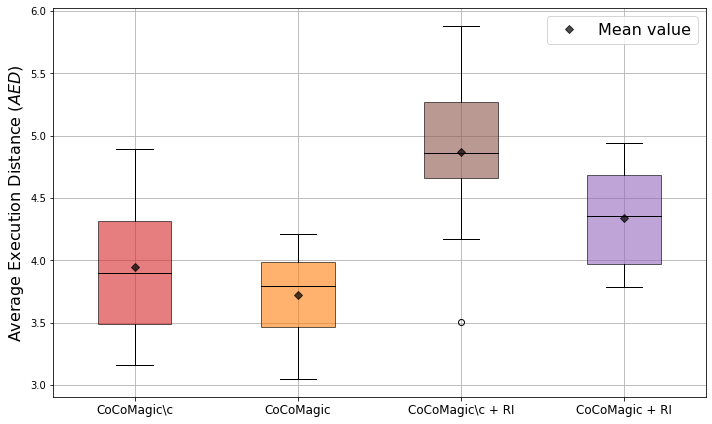

In [10]:
set3_aed = visualize_aed(rq3_projects)

# Fitness Distribution

Average Fitness improvement of ccea (1.29) compared to ccea-c (1.50): -14.08% (p-value = 9.2e-01)
Average Fitness improvement of ccea-c+ri (1.19) compared to ccea-c (1.50): -21.09% (p-value = 9.0e-01)
Average Fitness improvement of ccea+ri (0.75) compared to ccea-c (1.50): -49.93% (p-value = 1.0e+00)


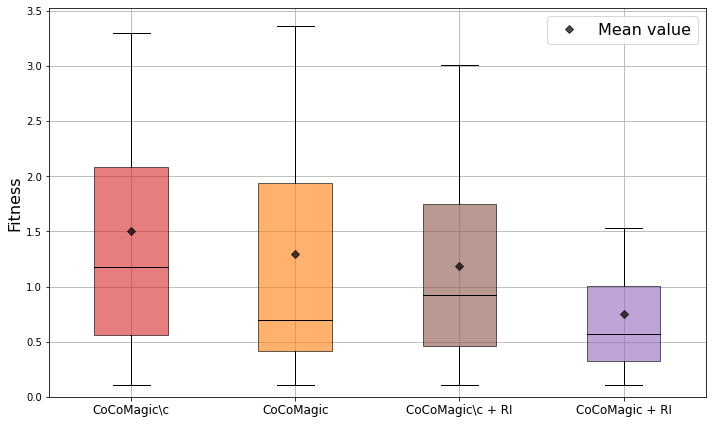

In [11]:
set3_fitnesses = visualize_fitness_distribution(
    rq3_projects,
    comparisons={'algs': ['ccea', 'ccea-c+ri', 'ccea+ri'], 'baselines': ['ccea-c']},
    vis_name="fitness_comparison.pdf",
)

# MR Group 3

# RQ1

In [ ]:
fitnesses, dists = quantile(mr3_data, min_fitness=0.0)
print('Fitness quantiles: ', np.quantile(fitnesses, [0.25, 0.5, 0.75, 0.9]).round(1), f', Average Fitness: {np.mean(fitnesses):.2f}')
print('Distance Quantiles: ', np.quantile(dists, [0.1, 0.25, 0.5]).round(1), f', Average Distance: {np.mean(dists):.2f}')

In [ ]:
set1_solution_stats = visualize_archived_distinct_solutions(
    mr3_data,
    comparisons = {'algs': ['ccea'], 'baselines': ['ga', 'rs']},
    # comparisons = None,
    fitness_thresholds=[0.0, 0.03, 0.06, 0.09, 0.12, 0.15],
    distance_thresholds=np.arange(0, 4.01, 0.4).round(1),
    mr_set=mr_set3,
    box=False,
    show=True
)

# RQ2

In [ ]:
visualize_distinct_solution_over_simulations(mr3_data,
    fitness_thresholds=[0.03, 0.1, 0.15], distance_thresholds=[1.0, 1.7, 2.2],
    max_sim_num=200, interval=10, mrc=False, mr_set=mr_set3, show=True)

In [ ]:
visualize_computational_efficiency_v2(mr3_data)